In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("survey lung cancer.csv")

# preview data
print(df.head())

# dataset info
print(df.info())

# shape of dataset
print(df.shape)

  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        1               2        2              1   
1      M   74        2               1        1              1   
2      F   59        1               1        1              2   
3      M   63        2               2        2              1   
4      F   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1         2         1         2                  2         2   
1                2         2         2         1                  1         1   
2                1         2         1         2                  1         2   
3                1         1         1         1                  2         1   
4                1         1         1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANCER  
0                    2                      

In [4]:
# remove extra spaces in column names
df.columns = df.columns.str.strip()

# convert categorical values
df['GENDER'] = df['GENDER'].map({'M':1,'F':0})
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES':1,'NO':0})

# check missing values
print(df.isnull().sum())

# summary statistics
print(df.describe())

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64
           GENDER         AGE     SMOKING  YELLOW_FINGERS     ANXIETY  \
count  309.000000  309.000000  309.000000      309.000000  309.000000   
mean     0.524272   62.673139    1.563107        1.569579    1.498382   
std      0.500221    8.210301    0.496806        0.495938    0.500808   
min      0.000000   21.000000    1.000000        1.000000    1.000000   
25%      0.000000   57.000000    1.000000        1.000000    1.000000   
50%      1.000000   62.000000    2.000000        2.000000    1.000000   
75%      1.000000   69.000000    2.000000   

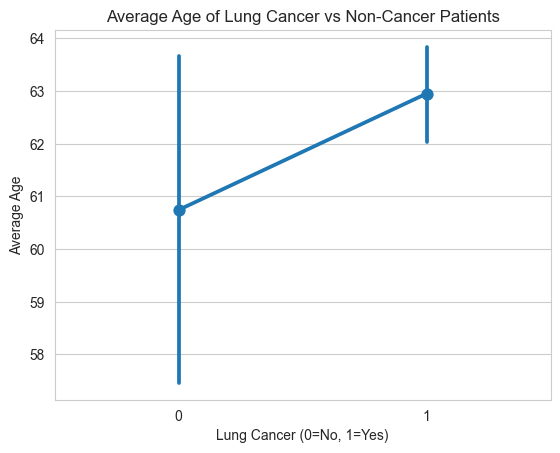

In [ ]:
#AVERAGE AGE OF LUNG CANCER PATIENTS
sns.pointplot(x='LUNG_CANCER', y='AGE', data=df)
plt.title("Average Age of Lung Cancer vs Non-Cancer Patients")
plt.xlabel("Lung Cancer (0=No, 1=Yes)")
plt.ylabel("Average Age")
plt.show()

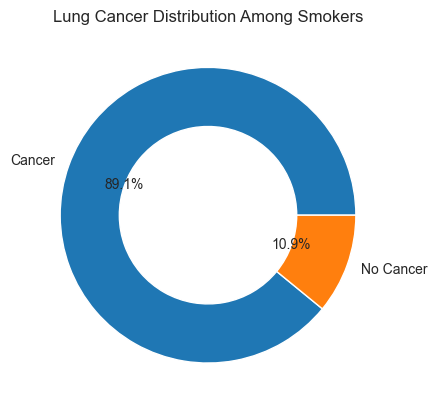

In [ ]:
#PERCENTAGE OF SMOKERS WITH LUNG CANCER
smoking_lung = df[df['SMOKING']==2]['LUNG_CANCER'].value_counts()

plt.pie(smoking_lung, labels=['Cancer','No Cancer'],
        autopct='%1.1f%%', wedgeprops=dict(width=0.4))

plt.title("Lung Cancer Distribution Among Smokers")
plt.show()

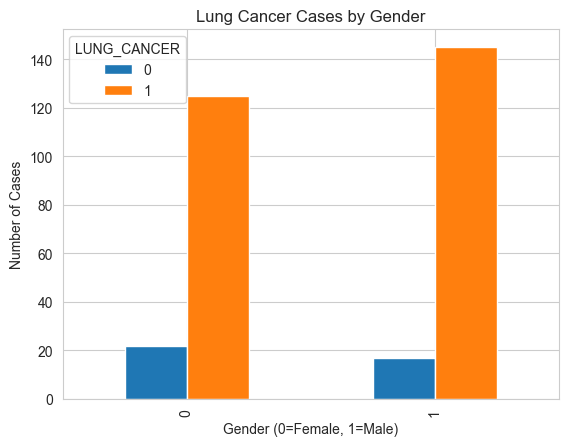

In [ ]:
#LUNG CANCER CASES BY GENDER
gender_cases = pd.crosstab(df['GENDER'], df['LUNG_CANCER'])

gender_cases.plot(kind='bar')
plt.title("Lung Cancer Cases by Gender")
plt.xlabel("Gender (0=Female, 1=Male)")
plt.ylabel("Number of Cases")
plt.show()

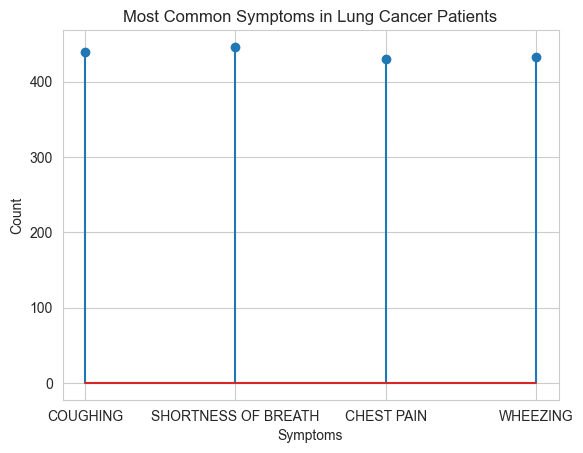

In [18]:
#COMMON SYMPTOMS OF LUNG CANCER CASES
symptoms = ['COUGHING','SHORTNESS OF BREATH','CHEST PAIN','WHEEZING']
symptom_counts = df[df['LUNG_CANCER']==1][symptoms].sum()

plt.stem(symptom_counts.index, symptom_counts.values)
plt.title("Most Common Symptoms in Lung Cancer Patients")
plt.xlabel("Symptoms")
plt.ylabel("Count")
plt.show()

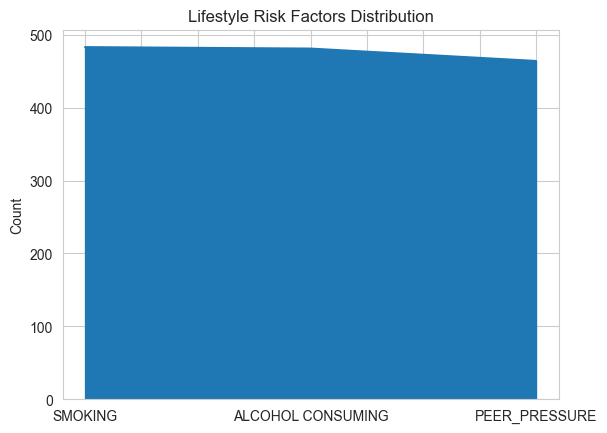

In [19]:
#LIFESTYLE RISK FACTOR
risk = ['SMOKING','ALCOHOL CONSUMING','PEER_PRESSURE']
risk_counts = df[risk].sum()

risk_counts.plot(kind='area')
plt.title("Lifestyle Risk Factors Distribution")
plt.ylabel("Count")
plt.show()

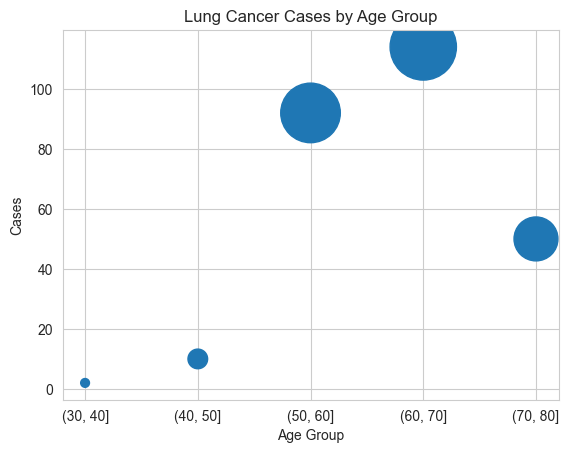

In [20]:
#LUNG CANCER BY AGE GROUP
df['Age_Group'] = pd.cut(df['AGE'], bins=[30,40,50,60,70,80])

age_cases = df.groupby('Age_Group')['LUNG_CANCER'].sum()

plt.scatter(age_cases.index.astype(str),
            age_cases.values,
            s=age_cases.values*20)

plt.title("Lung Cancer Cases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Cases")
plt.show()

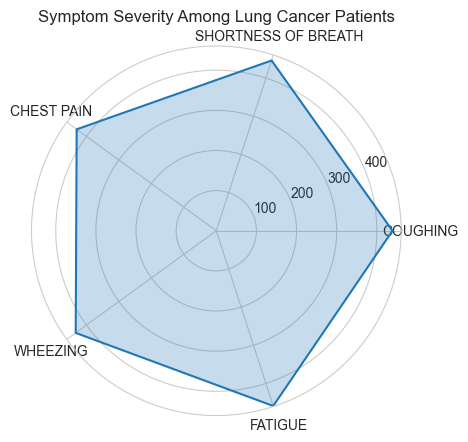

In [ ]:
#COMPARING MULTIPLE SYMPTOMS OF LUNG CANCER AT ONCE 
import numpy as np

symptoms = ['COUGHING','SHORTNESS OF BREATH','CHEST PAIN','WHEEZING','FATIGUE']
values = df[df['LUNG_CANCER']==1][symptoms].sum().values

angles = np.linspace(0, 2*np.pi, len(symptoms), endpoint=False)

values = np.concatenate((values,[values[0]]))
angles = np.concatenate((angles,[angles[0]]))

plt.figure()
ax = plt.subplot(111, polar=True)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)

ax.set_thetagrids(angles[:-1] * 180/np.pi, symptoms)
plt.title("Symptom Severity Among Lung Cancer Patients")

plt.show()

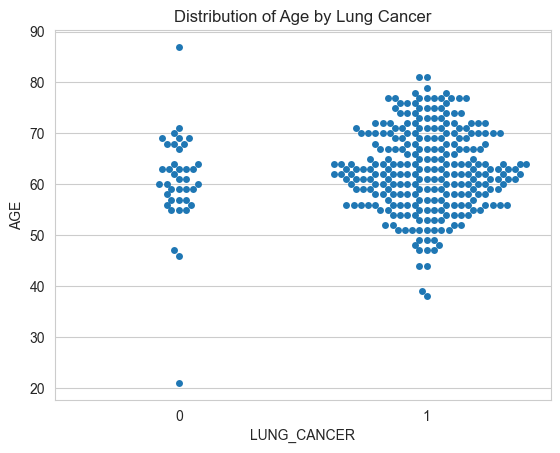

In [ ]:
#SYMPTOM DISTRIBUTION
import seaborn as sns
import matplotlib.pyplot as plt

sns.swarmplot(x='LUNG_CANCER', y='AGE', data=df)

plt.title("Distribution of Age by Lung Cancer")
plt.show()

In [41]:
df['Risk_Score'] = df['SMOKING'] + df['ALCOHOL CONSUMING'] + df['PEER_PRESSURE']

In [42]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER,Age_Group,Risk_Score
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1,"(60, 70]",4
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1,"(70, 80]",4
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0,"(50, 60]",4
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0,"(60, 70]",5
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0,"(60, 70]",3


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [45]:
print(X_train.dtypes)

GENDER                      int64
AGE                         int64
SMOKING                     int64
YELLOW_FINGERS              int64
ANXIETY                     int64
PEER_PRESSURE               int64
CHRONIC DISEASE             int64
FATIGUE                     int64
ALLERGY                     int64
WHEEZING                    int64
ALCOHOL CONSUMING           int64
COUGHING                    int64
SHORTNESS OF BREATH         int64
SWALLOWING DIFFICULTY       int64
CHEST PAIN                  int64
Age_Group                category
dtype: object


In [49]:
print(df['Age_Group'].dtype)

int8


In [50]:
df['Age_Group'] = df['Age_Group'].astype('category')

In [53]:
df['Age_Group'] = df['Age_Group'].cat.codes

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop("LUNG_CANCER", axis=1)
y = df["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [57]:
predictions = model.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.967741935483871


In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
print(cm)

[[ 1  1]
 [ 1 59]]


In [ ]:
#PREDICTION FOR NEW PERSON
model.predict([[1,65,2,2,1,2,1,2,1,2,2,2,2,2,2,6,2]])

C:\Users\medhini\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

In [62]:
df.to_csv("cleaned_lung_cancer_data.csv", index=False)